Found 24997 images belonging to 2 classes.
Found 19799 images belonging to 2 classes.
Epoch 1/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 161s 2s/step - accuracy: 0.5375 - loss: 0.6888 - val_accuracy: 0.5922 - val_loss: 0.6604
Epoch 2/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 123s 1s/step - accuracy: 0.6055 - loss: 0.6532 - val_accuracy: 0.6162 - val_loss: 0.6370
Epoch 3/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 106s 1s/step - accuracy: 0.6483 - loss: 0.6243 - val_accuracy: 0.6800 - val_loss: 0.5962
Epoch 4/50
 91/100 ━━━━━━━━━━━━━━━━━━━━ 5s 651ms/step - accuracy: 0.6578 - loss: 0.6104

c:\Users\PC\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


100/100 ━━━━━━━━━━━━━━━━━━━━ 87s 872ms/step - accuracy: 0.6659 - loss: 0.6072 - val_accuracy: 0.7138 - val_loss: 0.5568
Epoch 5/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 82s 825ms/step - accuracy: 0.6819 - loss: 0.5926 - val_accuracy: 0.6591 - val_loss: 0.6150
Epoch 6/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 70s 701ms/step - accuracy: 0.6961 - loss: 0.5821 - val_accuracy: 0.7378 - val_loss: 0.5342
Epoch 7/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 61s 616ms/step - accuracy: 0.6908 - loss: 0.5873 - val_accuracy: 0.7334 - val_loss: 0.5385
Epoch 8/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 52s 526ms/step - accuracy: 0.6949 - loss: 0.5763 - val_accuracy: 0.7381 - val_loss: 0.5171
Epoch 9/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 54s 542ms/step - accuracy: 0.7019 - loss: 0.5650 - val_accuracy: 0.7516 - val_loss: 0.5054
Epoch 10/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 51s 511ms/step - accuracy: 0.7023 - loss: 0.5670 - val_accuracy: 0.7616 - val_loss: 0.5093
Epoch 11/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 48s 480ms/step - accuracy: 0.7133 - loss: 0.5563 - v

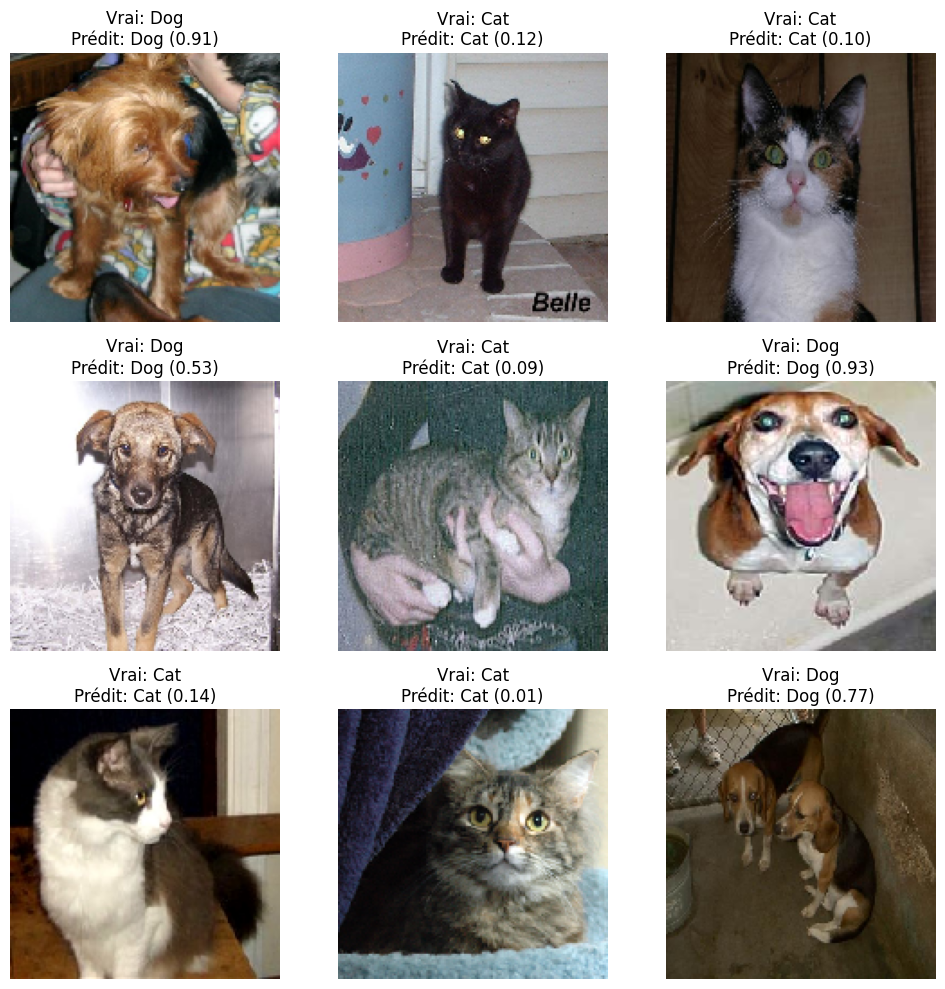

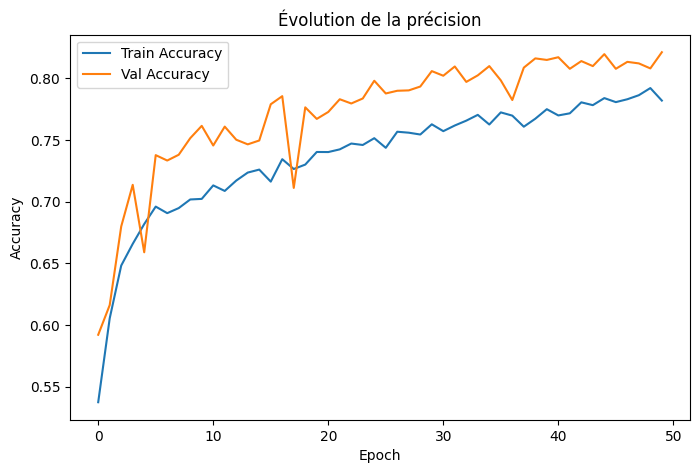

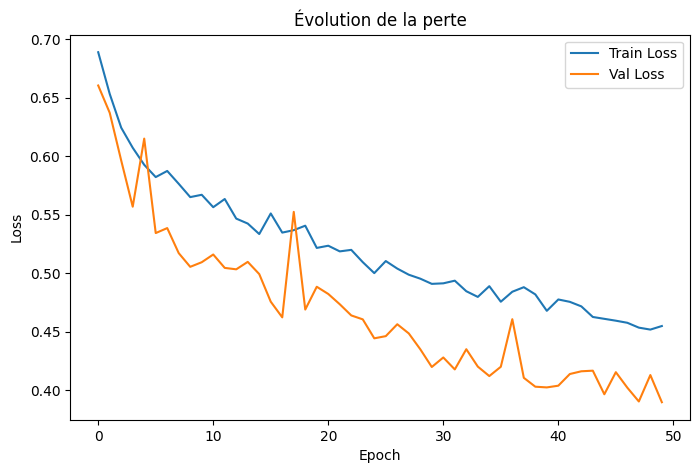

In [ ]:

# ===============================
# 1 IMPORTER LES BIBLIOTHÈQUES
# ===============================
import os                  # pour gérer les chemins de fichiers/dossiers
import random              # pour mélanger les images avant le découpage
import shutil              # pour copier les fichiers
from PIL import Image      # pour vérifier les images corrompues
import matplotlib.pyplot as plt  # pour afficher les images et les graphiques

# Bibliothèques de Deep Learning
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam

# ===============================
# 2️ DÉFINIR LES CHEMINS
# ===============================

base_dir = r"C:/Users/PC/Desktop/DL/cats-vs-dogs/PetImages"  

# Création automatique des dossiers d'entraînement et de validation
train_dir = os.path.join(base_dir, 'train')
val_dir = os.path.join(base_dir, 'validation')

# ===============================
# 3️ CRÉER LES DOSSIERS NÉCESSAIRES
# ===============================
# On crée les sous-dossiers pour 'Cat' et 'Dog' dans train et validation
for folder in [os.path.join(train_dir, 'Cat'),
               os.path.join(train_dir, 'Dog'),
               os.path.join(val_dir, 'Cat'),
               os.path.join(val_dir, 'Dog')]:
    os.makedirs(folder, exist_ok=True)  # évite les erreurs si le dossier existe déjà

# ===============================
# 4️ SUPPRIMER LES IMAGES CORROMPUES
# ===============================
# Certaines images de PetImages sont inutilisables (fichiers cassés)
for cls in ['Cat', 'Dog']:
    cls_path = os.path.join(base_dir, cls)
    for f in os.listdir(cls_path):
        f_path = os.path.join(cls_path, f)
        try:
            img = Image.open(f_path)
            img.verify()  # Vérifie l'intégrité du fichier
        except:
            os.remove(f_path)  # Supprime si l’image est illisible

# ===============================
# 5️ DIVISER LE DATASET EN TRAIN / VALIDATION
# ===============================
for cls in ['Cat', 'Dog']:
    images = os.listdir(os.path.join(base_dir, cls))
    random.shuffle(images)  # Mélange aléatoire
    split = int(len(images) * 0.8)  # 80% pour l'entraînement

    # Copier les images dans les bons dossiers
    for i, img in enumerate(images):
        src_path = os.path.join(base_dir, cls, img)
        if i < split:
            dst_path = os.path.join(train_dir, cls, img)
        else:
            dst_path = os.path.join(val_dir, cls, img)
        shutil.copy2(src_path, dst_path)

# ===============================
# 6️ PRÉTRAITEMENT & AUGMENTATION
# ===============================
# L’augmentation génère des images modifiées pour enrichir le dataset
train_datagen = ImageDataGenerator(
    rescale=1./255,           # normalisation entre 0 et 1
    rotation_range=40,        # rotation aléatoire jusqu’à 40°
    width_shift_range=0.2,    # translation horizontale
    height_shift_range=0.2,   # translation verticale
    shear_range=0.2,          # cisaillement
    zoom_range=0.2,           # zoom
    horizontal_flip=True,     # retournement horizontal
    fill_mode='nearest'       # remplissage des zones manquantes
)

valid_datagen = ImageDataGenerator(rescale=1./255)  # seulement normalisation

# Générateurs d'images
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(150,150),    # toutes les images sont redimensionnées à 150x150
    batch_size=64,            # nombre d’images par lot
    class_mode='binary'       # classification binaire (chat=0, chien=1)
)

validation_generator = valid_datagen.flow_from_directory(
    val_dir,
    target_size=(150,150),
    batch_size=64,
    class_mode='binary'
)

# ===============================
# 7️⃣ CONSTRUCTION DU CNN
# ===============================
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(150,150,3)),  # 1er bloc convolution
    MaxPooling2D((2,2)),                                            # réduction de taille
    Conv2D(64, (3,3), activation='relu'),                           # 2e bloc
    MaxPooling2D((2,2)),
    Conv2D(128, (3,3), activation='relu'),                          # 3e bloc
    MaxPooling2D((2,2)),
    Flatten(),                                                      # transformation en vecteur
    Dropout(0.5),                                                   # désactive aléatoirement des neurones
    Dense(512, activation='relu'),                                  # couche entièrement connectée
    Dense(1, activation='sigmoid')                                  # sortie binaire (chat/chien)
])

# ===============================
# 8️ COMPILATION DU MODÈLE
# ===============================
model.compile(
    loss='binary_crossentropy',      # pour classification binaire
    optimizer=Adam(learning_rate=1e-4),
    metrics=['accuracy']             # suivi de la précision
)

# ===============================
# 9️ ENTRAÎNEMENT DU MODÈLE
# ===============================
history = model.fit(
    train_generator,
    steps_per_epoch=100,             # nombre de lots par epoch
    epochs=50,                       # tu peux augmenter jusqu’à 50 pour de meilleures performances
    validation_data=validation_generator,
    validation_steps=50
)

# ===============================
#  ÉVALUATION DU MODÈLE
# ===============================
loss, accuracy = model.evaluate(validation_generator, steps=50)
print(f"\nLoss sur validation : {loss:.4f}, Accuracy : {accuracy*100:.2f}%")

# ===============================
# 1 1 AFFICHAGE DE PRÉDICTIONS
# ===============================
images, labels = next(validation_generator)  # prend un batch
preds = model.predict(images[:9])

# Afficher 9 images dans une grille 3x3
fig, axes = plt.subplots(3, 3, figsize=(10,10))
axes = axes.flatten()

for i in range(9):
    axes[i].imshow(images[i])
    axes[i].set_title(f"Vrai: {'Dog' if labels[i]==1 else 'Cat'}\nPrédit: {'Dog' if preds[i]>0.5 else 'Cat'} ({preds[i][0]:.2f})")
    axes[i].axis('off')

plt.tight_layout()
plt.show()

# ===============================
# 1️ 2 COURBES D’APPRENTISSAGE
# ===============================
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Évolution de la précision')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Évolution de la perte')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

